# Presentation II — SGD applied to a CNN to detect malaria

 **Analysis of Algorithms**: formal definition, complexity, convergence, sensitivity to learning rate, and execution time.

> Class: `Parasitized = 1`, `Uninfected = 0`.


## 1. mports and seeds

The seed allows for repeating experiments and comparing results with less variation.


In [ ]:
import os
import time
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

SEED = 1000
np.random.seed(SEED)
tf.random.set_seed(SEED)



## 2. Load dataset




In [ ]:

zip_path = "/content/Reduced_data-20241129T182028Z-001.zip"
extract_path = "/content/sample_data"
data_dir = os.path.join(extract_path, "Reduced_data")

if os.path.exists(zip_path):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Uncompressed file in:", extract_path)
else:
    print("The ZIP file was not found. If you already have the extracted folder, check data_dir:", data_dir)


Archivo descomprimido en: /content/sample_data


## 3. Create Image DataFrame

Here the `filepath, label` table is built.


In [ ]:
def build_dataframe(data_dir):
    class_map = {
        'Parasitized': 1,
        'Uninfected': 0,
    }
    records = []
    for class_name, label in class_map.items():
        folder = Path(data_dir) / class_name
        if not folder.exists():
            raise FileNotFoundError(f"The folder does not exist: {folder}")
        for image_name in os.listdir(folder):
            if image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                records.append({
                    'filepath': str(folder / image_name),
                    'label': label
                })
    return pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)

df_images = build_dataframe(data_dir)
print(df_images.head())
print("Total imágenes:", len(df_images))
print(df_images['label'].value_counts().rename(index={0: 'Uninfected', 1: 'Parasitized'}))


                                            filepath  label
0  /content/sample_data/Reduced_data/Uninfected/C...      0
1  /content/sample_data/Reduced_data/Parasitized/...      1
2  /content/sample_data/Reduced_data/Parasitized/...      1
3  /content/sample_data/Reduced_data/Uninfected/C...      0
4  /content/sample_data/Reduced_data/Uninfected/C...      0
Total imágenes: 1067
label
Uninfected     567
Parasitized    500
Name: count, dtype: int64


## 4. Train/test division and preprocessing


We use `64 × 64 × 3` images to reduce computational cost and facilitate time analysis.


In [ ]:
train_df, test_df = train_test_split(
    df_images,
    test_size=0.20,
    random_state=SEED,
    stratify=df_images['label']
)

def load_images_from_df(df, size=64):
    X, y = [], []
    for _, row in df.iterrows():
        img = cv2.imread(row['filepath'])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size))
        X.append(img.astype(np.float32) / 255.0)
        y.append(int(row['label']))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = load_images_from_df(train_df, size=64)
X_test, y_test = load_images_from_df(test_df, size=64)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (853, 64, 64, 3)
X_test: (214, 64, 64, 3)
y_train: (853,)
y_test: (214,)


## 5. Quick overview of


---

examples

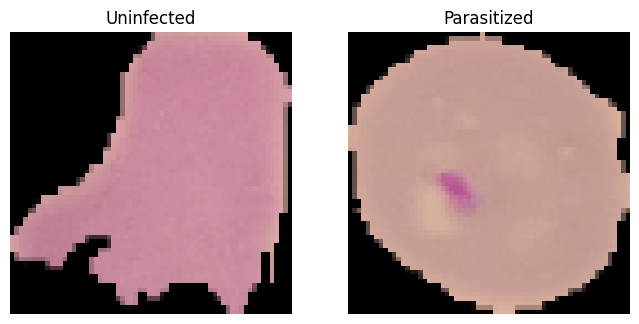

In [ ]:
plt.figure(figsize=(8, 4))
for i, label_name in enumerate(['Uninfected', 'Parasitized']):
    label = 0 if label_name == 'Uninfected' else 1
    idx = np.where(y_train == label)[0][0]
    plt.subplot(1, 2, i + 1)
    plt.imshow(X_train[idx])
    plt.title(label_name)
    plt.axis('off')
plt.show()


## 6. Formal Definition of SGD
The algorithm minimizes an empirical loss function. For a neural network with parameters $\theta$, SGD updates the weights using a sample or a mini-batch:$$\theta_{t+1}=\theta_t-\eta\nabla_\theta L(\theta_t;B_t)$$Where:- $\theta_t$: network parameters at iteration $t$ - $\eta$: learning rate - $B_t$: selected mini-batch - $L$: binary cross-entropy in this problem.
In this version we use **pure SGD**:
`momentum=0.0`, `nesterov=False`.\n

## 7. CNN model trained only with SGD


A small CNN is used so that the protagonist of the project is the optimization algorithm, not a giant architecture.


In [ ]:
def build_cnn_sgd(input_shape=(64, 64, 3), learning_rate=0.01):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=0.0,
        nesterov=False
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_example = build_cnn_sgd(learning_rate=0.01)
model_example.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,625 (1.55 MB)

 Trainable params: 406,625 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Callback to measure time by era


In [ ]:
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.start_time)


## 9. Experiments for empirical analysis


For this presentation, these three experiments are sufficient:

1. SGD with a medium learning rate.

2. SGD with a low learning rate.

3. SGD with a larger batch size.

This allows you to discuss convergence, sensitivity, and cost per epoch.

In [ ]:
experiments = [
    {'name': 'SGD_lr_0.01_bs_32', 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 30},
    {'name': 'SGD_lr_0.001_bs_32', 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 30},
    {'name': 'SGD_lr_0.01_bs_128', 'learning_rate': 0.01, 'batch_size': 128, 'epochs': 30},
]


## 10. Training and measurement


In [ ]:
all_metrics = []
all_histories = []
models = {}

for exp in experiments:
    print("\n==============================")
    print("Experiment:", exp['name'])
    print("==============================")

    model = build_cnn_sgd(learning_rate=exp['learning_rate'])
    timer = EpochTimer()

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=exp['epochs'],
        batch_size=exp['batch_size'],
        callbacks=[timer],
        verbose=1
    )
    total_time = time.time() - start

    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'experiment': exp['name'],
        'learning_rate': exp['learning_rate'],
        'batch_size': exp['batch_size'],
        'epochs': exp['epochs'],
        'test_accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'total_time_sec': total_time,
        'avg_epoch_time_sec': np.mean(timer.epoch_times),
    }
    all_metrics.append(metrics)

    hist_df = pd.DataFrame(history.history)
    hist_df['epoch'] = np.arange(1, len(hist_df) + 1)
    hist_df['experiment'] = exp['name']
    hist_df['epoch_time_sec'] = timer.epoch_times
    all_histories.append(hist_df)

    models[exp['name']] = model

results_metrics = pd.DataFrame(all_metrics).sort_values('test_accuracy', ascending=False)
results_history = pd.concat(all_histories, ignore_index=True)

print(results_metrics)



Experimento: SGD_lr_0.01_bs_32
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5163 - loss: 0.6922 - val_accuracy: 0.5698 - val_loss: 0.6765
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.5293 - loss: 0.6882 - val_accuracy: 0.5698 - val_loss: 0.6716
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.5476 - loss: 0.6840 - val_accuracy: 0.5698 - val_loss: 0.6679
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.5645 - loss: 0.6805 - val_accuracy: 0.5581 - val_loss: 0.6651
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5841 - loss: 0.6770 - val_accuracy: 0.5581 - val_loss: 0.6620
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.6037 - loss: 0.6730 - val_accuracy: 0.5581 - val_loss: 0.6587
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.6141 - loss: 0.6693 - val_accuracy: 0.5698 - val_loss: 0.6554
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.6193 - loss

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
           experiment  learning_rate  batch_size  epochs  test_accuracy  \
0   SGD_lr_0.01_bs_32          0.010          32      30       0.700935   
2  SGD_lr_0.01_bs_128          0.010         128      30       0.584112   
1  SGD_lr_0.001_bs_32          0.001          32      30       0.570093   

   precision  recall  f1_score  total_time_sec  avg_epoch_time_sec  
0   0.625000    0.90  0.737705       81.094591            2.678173  
2   0.761905    0.16  0.264463       74.957472            2.491897  
1   0.900000    0.09  0.163636       82.832583            2.679015  


## 11. Convergence curves


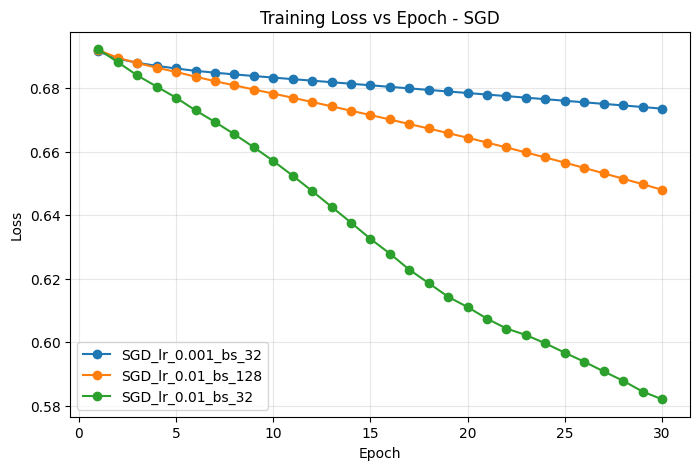

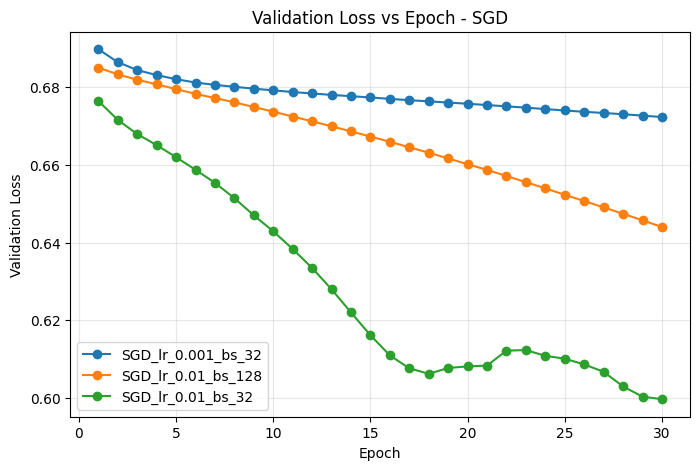

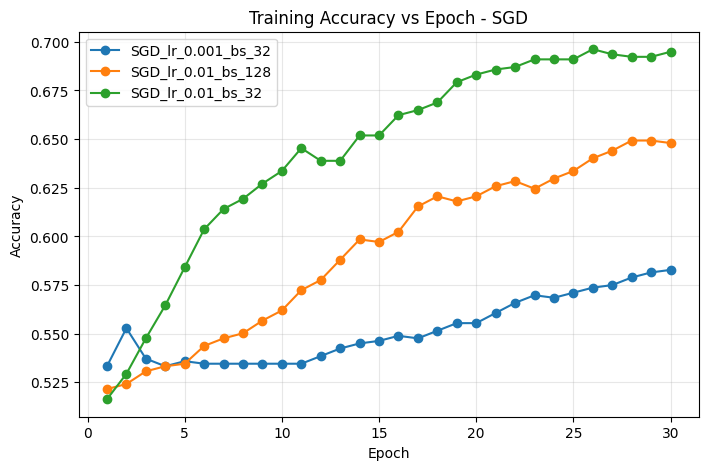

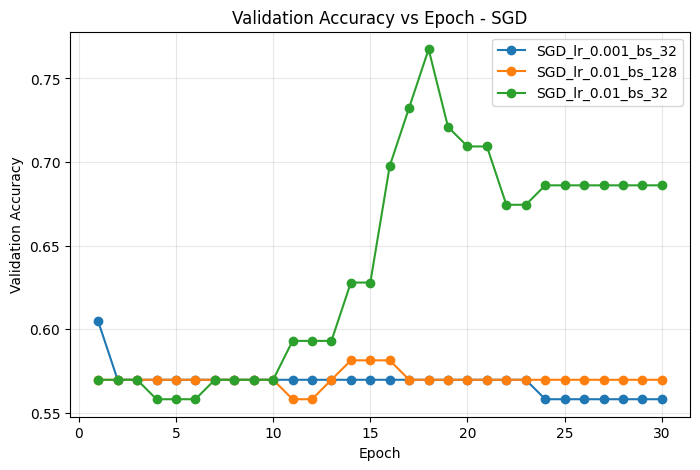

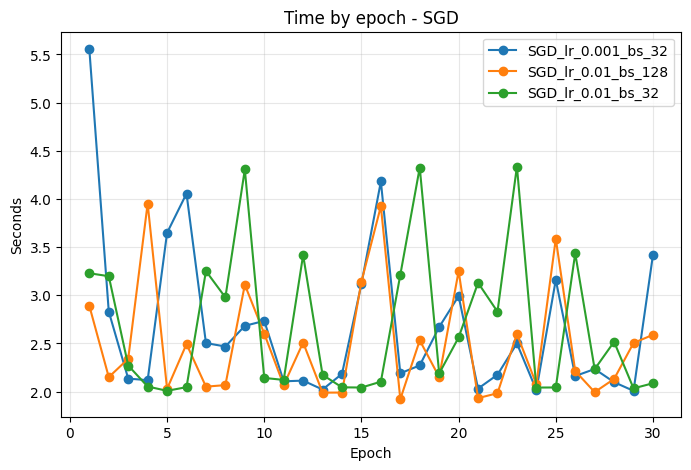

In [ ]:
def plot_metric(history_df, metric, title, ylabel):
    plt.figure(figsize=(8, 5))
    for name, group in history_df.groupby('experiment'):
        plt.plot(group['epoch'], group[metric], marker='o', label=name)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_metric(results_history, 'loss', 'Training Loss vs Epoch - SGD', 'Loss')
plot_metric(results_history, 'val_loss', 'Validation Loss vs Epoch - SGD', 'Validation Loss')
plot_metric(results_history, 'accuracy', 'Training Accuracy vs Epoch - SGD', 'Accuracy')
plot_metric(results_history, 'val_accuracy', 'Validation Accuracy vs Epoch - SGD', 'Validation Accuracy')
plot_metric(results_history, 'epoch_time_sec', 'Time by epoch - SGD', 'Seconds')


## 12. Final evaluation of the best experiment


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Mejor experimento: SGD_lr_0.01_bs_32
              precision    recall  f1-score   support

  Uninfected       0.86      0.53      0.65       114
 Parasitized       0.62      0.90      0.74       100

    accuracy                           0.70       214
   macro avg       0.74      0.71      0.69       214
weighted avg       0.75      0.70      0.69       214



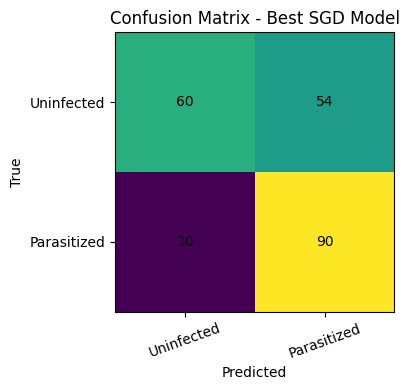

In [ ]:
best_name = results_metrics.iloc[0]['experiment']
best_model = models[best_name]

y_prob_best = best_model.predict(X_test).ravel()
y_pred_best = (y_prob_best >= 0.5).astype(int)

print("Mejor experimento:", best_name)
print(classification_report(y_test, y_pred_best, target_names=['Uninfected', 'Parasitized'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix - Best SGD Model')
plt.xticks([0, 1], ['Uninfected', 'Parasitized'], rotation=20)
plt.yticks([0, 1], ['Uninfected', 'Parasitized'])
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.tight_layout()
plt.show()


## 13. Complexity analysis for the report
We can explain the complexity of SGD like this:- Let $N$ be the number of training images.- Let $E$ be the number of epochs- Let $B$ be the batch size.- Let $C_f$ be the cost of a forward pass of the CNN for an image- Let $C_b$ be the backpropagation cost for an image. In practice, $C_b$ is usually of the same order as $C_f$.**Cost per mini-batch:**$$O(B(C_f+C_b))$$**Number of updates per epoch:**$$\left\lceil \frac{N}{B} \right\rceil$$**Cost per epoch:**$$O(N(C_f+C_b))$$**Total cost:**$$O(E\,N(C_f+C_b))$$Important interpretation: Increasing `batch_size` reduces the number of updates per epoch, but each update processes more images. Therefore, the total time does not always decrease linearly.
mpre baja linealmente.

## 14. Save results for report


In [ ]:
out_dir = 'results_sgd'
os.makedirs(out_dir, exist_ok=True)

results_metrics.to_csv(os.path.join(out_dir, 'summary_metrics.csv'), index=False)
results_history.to_csv(os.path.join(out_dir, 'training_history.csv'), index=False)
best_model.save(os.path.join(out_dir, 'best_sgd_model.keras'))

print('Resultados guardados en:', out_dir)


Resultados guardados en: results_sgd


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


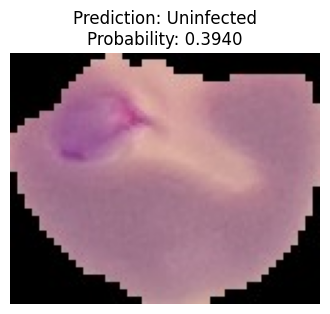

Probability of being infected: 0.39397252
Final prediction: Uninfected


('Uninfected', np.float32(0.39397252))

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_new_image(model, image_path, image_size=64):
    # Leer imagen
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("The image could not be read. Please check the file path.")

    # Convertir de BGR a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar igual que en el entrenamiento
    img_resized = cv2.resize(img_rgb, (image_size, image_size))

    # Normalizar igual que el dataset
    img_normalized = img_resized.astype(np.float32) / 255.0

    # Agregar dimensión batch
    input_image = np.expand_dims(img_normalized, axis=0)

    # Predicción
    probability = model.predict(input_image)[0][0]

    # Clasificación
    if probability >= 0.5:
        predicted_class = "Parasitized"
    else:
        predicted_class = "Uninfected"

    # Mostrar resultado
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}\nProbability: {probability:.4f}")
    plt.show()

    print("Probability of being infected:", probability)
    print("Final prediction:", predicted_class)

    return predicted_class, probability


# Aquí pones tu imagen nueva
image_path = "/content/WhatsApp Image 2026-04-16 at 2.33.28 PM.jpeg"

predict_new_image(model, image_path)